# Excercises 

## 0. Setup your own repo
- Dont work in this repo. This is my material for lessons. Set up your own repo to work in. Use `MADS-ML-{yourname}` as a format, eg `MADS-ML-JoostB`.
- You can add `mads_datasets` and `mltrainer` as dependencies to your own repo, in addition to more basic things like jupyter, torch and seaborn.
- If you want to use the tomlserializer, add `tomlserializer` as a dependency. For tensorboard, add `tensorboard` and `torch-tb-profiler`.
- Invite me (raoulg; https://github.com/raoulg) as a collaborator to your repo.

# 1. Tune the network
Run the experiment below, explore the different parameters (see suggestions below) and study the result with tensorboard. 
Make a single page (1 a4) report of your findings. Use your visualisation skills to communicate your most important findings.

In [1]:
import torch.optim as optim
from mads_datasets import DatasetFactoryProvider, DatasetType
from mltrainer import ReportTypes, Trainer, TrainerSettings, metrics
from mltrainer.preprocessors import BasePreprocessor
from tomlserializer import TOMLSerializer
from torch import nn

We will be using `tomlserializer` to easily keep track of our experiments, and to easily save the different things we did during our experiments.
It can export things like settings and models to a simple `toml` file, which can be easily shared, checked and modified.

First, we need the data. 

In [2]:
fashionfactory = DatasetFactoryProvider.create_factory(DatasetType.FASHION)
preprocessor = BasePreprocessor()
streamers = fashionfactory.create_datastreamer(batchsize=64, preprocessor=preprocessor)
train = streamers["train"]
valid = streamers["valid"]
trainstreamer = train.stream()
validstreamer = valid.stream()

2026-06-16 18:15:55.451 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /Users/vince/.cache/mads_datasets/fashionmnist


2026-06-16 18:15:55.451 | INFO     | mads_datasets.base:download_data:124 - File already exists at /Users/vince/.cache/mads_datasets/fashionmnist/fashionmnist.pt


We need a way to determine how well our model is performing. We will use accuracy as a metric.

In [3]:
accuracy = metrics.Accuracy()

You can set up a single experiment.

- We will show the model batches of 64 images, 
- and for every epoch we will show the model 100 batches (trainsteps=100).
- then, we will test how well the model is doing on unseen data (teststeps=100).
- we will report our results during training to tensorboard, and report all configuration to a toml file.
- we will log the results into a directory called "modellogs", but you could change this to whatever you want.

In [4]:
import torch

loss_fn = torch.nn.CrossEntropyLoss()

settings = TrainerSettings(
    epochs=3,
    metrics=[accuracy],
    logdir="modellogs",
    train_steps=100,
    valid_steps=100,
    reporttypes=[ReportTypes.TENSORBOARD, ReportTypes.TOML],
)


We will use a very basic model: a model with three linear layers.

In [5]:
class NeuralNetwork(nn.Module):
    def __init__(self, num_classes: int, units1: int, units2: int) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.units1 = units1
        self.units2 = units2
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, units1),
            nn.ReLU(),
            nn.Linear(units1, units2),
            nn.ReLU(),
            nn.Linear(units2, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork(
    num_classes=10, units1=256, units2=256)

I developped the `tomlserializer` package, it is a useful tool to save configs, models and settings as a tomlfile; that way it is easy to track what you changed during your experiments.

This package will 1. check if there is a `__dict__` attribute available, and if so, it will use that to extract the parameters that do not start with an underscore, like this:

In [6]:
{k: v for k, v in model.__dict__.items() if not k.startswith("_")}

{'training': True, 'num_classes': 10, 'units1': 256, 'units2': 256}

This means that if you want to add more parameters to the `.toml` file, eg `units3`, you can add them to the class like this:

```python
class NeuralNetwork(nn.Module):
    def __init__(self, num_classes: int, units1: int, units2: int, units3: int) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.units1 = units1
        self.units2 = units2
        self.units3 = units3  # <-- add this line
```

And then it will be added to the `.toml` file. Check the result for yourself by using the `.save()` method of the `TomlSerializer` class like this:

In [7]:
tomlserializer = TOMLSerializer()
tomlserializer.save(settings, "settings.toml")
tomlserializer.save(model, "model.toml")

Check the `settings.toml` and `model.toml` files to see what is in there.

You can use the `Trainer` class from my `mltrainer` module to train your model. It has the TOMLserializer integrated, so it will automatically save the settings and model to a toml file if you have added `TOML` as a reporttype in the settings.

In [8]:
trainer = Trainer(
    model=model,
    settings=settings,
    loss_fn=loss_fn,
    optimizer=optim.Adam,
    traindataloader=trainstreamer,
    validdataloader=validstreamer,
    scheduler=optim.lr_scheduler.ReduceLROnPlateau
)
trainer.loop()

2026-06-16 18:15:55.480 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to modellogs/20260616-181555


2026-06-16 18:15:55.942 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

 86%|████████▌ | 86/100 [00:00<00:00, 851.98it/s]

...

 83%|████████▎ | 83/100 [00:00<00:00, 824.09it/s]

100%|██████████| 100/100 [00:00<00:00, 842.82it/s]


2026-06-16 18:15:56.437 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.5237 test 0.5076 metric ['0.8183']


100%|██████████| 3/3 [00:00<00:00,  6.65it/s]

100%|██████████| 3/3 [00:00<00:00,  6.65it/s]

Now, check in the modellogs directory the results of your experiment.

We can now loop this with a naive approach, called a grid-search (why do you think i call it naive?).

In [9]:
units = [256, 128, 64]
for unit1 in units:
    for unit2 in units:
        print(f"Units: {unit1}, {unit2}")

Units: 256, 256
Units: 256, 128
Units: 256, 64
Units: 128, 256
Units: 128, 128
Units: 128, 64
Units: 64, 256
Units: 64, 128
Units: 64, 64


Of course, this might not be the best way to search for a model; some configurations will be better than others (can you predict up front what will be the best configuration?).

So, feel free to improve upon the gridsearch by adding your own logic.

In [10]:
import torch

units = [256, 128, 64]
loss_fn = torch.nn.CrossEntropyLoss()

settings = TrainerSettings(
    epochs=3,
    metrics=[accuracy],
    logdir="modellogs",
    train_steps=len(train),
    valid_steps=len(valid),
    reporttypes=[ReportTypes.TENSORBOARD, ReportTypes.TOML],
)

for unit1 in units:
    for unit2 in units:

        model = NeuralNetwork(num_classes=10, units1=unit1, units2=unit2)

        trainer = Trainer(
            model=model,
            settings=settings,
            loss_fn=loss_fn,
            optimizer=optim.Adam,
            traindataloader=trainstreamer,
            validdataloader=validstreamer,
            scheduler=optim.lr_scheduler.ReduceLROnPlateau
        )
        trainer.loop()


2026-06-16 18:15:56.446 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to modellogs/20260616-181556


2026-06-16 18:15:56.447 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

 11%|█         | 99/937 [00:00<00:00, 986.56it/s]

...

 88%|████████▊ | 823/937 [00:00<00:00, 1377.46it/s]

100%|██████████| 937/937 [00:00<00:00, 1364.86it/s]

2026-06-16 18:16:17.981 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.3645 test 0.4016 metric ['0.8539']


100%|██████████| 3/3 [00:02<00:00,  1.38it/s]

100%|██████████| 3/3 [00:02<00:00,  1.39it/s]

Because we have set the ReportType to TOML, you will find in every log dir a model.toml and settings.toml file.

Run the experiment, and study the result with tensorboard. 

Locally, it is easy to do that with VS code itself. On the server, you have to take these steps:

- in the terminal, `cd` to the location of the repository
- activate the python environment for the shell. Note how the correct environment is being activated.
- run `tensorboard --logdir=modellogs` in the terminal
- tensorboard will launch at `localhost:6006` and vscode will notify you that the port is forwarded
- you can either press the `launch` button in VScode or open your local browser at `localhost:6006`


# Report
## 1. experiment
Experiment with things like:
- change the number of epochs, eg to 5 or 10. 
- changing the amount of units1 and units2 to values between 16 and 1024. Use factors of 2 to easily scan the ranges: 16, 32, 64, etc.
- changing the batchsize to values between 4 and 128. Again, use factors of two for convenience.
- change the depth of your model by adding a additional linear layer + activation function
- changing the learningrate to values between 1e-2 and 1e-5 
- changing the optimizer from SGD to one of the other available algoritms at [torch](https://pytorch.org/docs/stable/optim.html) (scroll down for the algorithms)

Check the results:
- all your experiments are saved in the `modellogs` directory, with a timestamp. Inside you find a model.toml file, that 
contains all the settings of the model. The `events` file is what tensorboard will show.
- visualize the relationship between variables: for example, make a heatmap of units vs layers.

Studyquestions:
- Epochs: what is the upside, what is the downside of increasing epochs? Do you need more epochs to find out which configuration is best? When do you need that, when not?
- what is an upside of using factors of 2 for hypertuning? What is a downside?

## Note
A note on train_steps: this is a setting that determines how often you get an update. 
Because our complete dataset is 938 (60000 / 64) batches long, you will need 938 trainstep to cover the complete 60.000 images.

This can actually be a bit confusion for some students, because changing the value of trainsteps 938 changes the meaning of an `epoch` slightly, because one epoch is no longer the full dataset, but simply `trainstep` batches. Setting trainsteps to 100 means you need to wait twice as long before you get feedback on the performance, as compared to trainsteps=50. You will see that settings trainsteps to 100 improves the learning, but that is simply because the model has seen twice as much examples as compared to trainsteps=50.

This implies that it is not usefull to compare trainsteps=50 and trainsteps=100, because setting it to 100 will always be better.
Just pick an amount that works for your hardware & patience, and adjust your number of epochs accordingly (increase epochs with lower values for trainsteps)

# 2. Reflect
Doing a master means you don't just start engineering a pipeline, but you need to reflect. Why do you see the results you see? What does this mean, considering the theory? Write down lessons learned and reflections, based on experimental results. This is the `science` part of `data science`.

You follow this cycle:
- make a hypothesis
- design an experiment
- run the experiment
- analyze the results and draw conclusions
- repeat

## Tip
To keep track of this process, it is useful to keep a journal. While you could use anything to do so, a nice command line tool is [jrnl](https://jrnl.sh/en/stable/). This gives you the advantage of staying in the terminal, just type down your ideas during the process, and you can always look back at what you have done.
Try to first formulate a hypothesis, and then design an experiment to test it. This will help you to stay focused on the goal, and not get lost in the data.

Important: the report you write is NOT the same as your journal! The journal will help you to keep track of your process, and later write down a reflection on what you have done where you draw conclusion, reflecting back on the theory.

# 3. Make a short report
Make a short 1 a4 page report of your findings.
pay attention to:
- what was your hypothesis about interaction between hyperparameters?
- what did you find?
- visualise your results about the relationship between hyperparameters.


# Experiments

## Setup
Re-initialize data and imports. We keep `train_steps=len(train)` and `valid_steps=len(valid)` fixed across all experiments so comparisons are fair (one epoch = full dataset pass).

In [11]:
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.optim as optim
from loguru import logger
from mads_datasets import DatasetFactoryProvider, DatasetType
from mltrainer import ReportTypes, Trainer, TrainerSettings, metrics
from mltrainer.preprocessors import BasePreprocessor
from tomlserializer import TOMLSerializer
from torch import nn

%matplotlib inline

accuracy = metrics.Accuracy()
loss_fn = torch.nn.CrossEntropyLoss()

# Collect all experiment results for in-notebook analysis
results: list[dict[str, Any]] = []

In [12]:
def create_data(batchsize: int = 64) -> tuple:
    """Create fresh data streamers for a given batchsize."""
    factory = DatasetFactoryProvider.create_factory(DatasetType.FASHION)
    preprocessor = BasePreprocessor()
    streamers = factory.create_datastreamer(batchsize=batchsize, preprocessor=preprocessor)
    train_ds = streamers["train"]
    valid_ds = streamers["valid"]
    return train_ds, valid_ds


def run_experiment(
    model: nn.Module,
    optimizer_cls: type,
    lr: float,
    epochs: int,
    batchsize: int,
    experiment_name: str,
) -> dict[str, Any]:
    """Run a single training experiment and return config + final metrics."""
    train_ds, valid_ds = create_data(batchsize=batchsize)

    settings = TrainerSettings(
        epochs=epochs,
        metrics=[accuracy],
        logdir="modellogs",
        train_steps=len(train_ds),
        valid_steps=len(valid_ds),
        reporttypes=[ReportTypes.TENSORBOARD, ReportTypes.TOML],
        optimizer_kwargs={"lr": lr, "weight_decay": 1e-5},
        scheduler_kwargs={"factor": 0.5, "patience": 2},
    )

    trainer = Trainer(
        model=model,
        settings=settings,
        loss_fn=loss_fn,
        optimizer=optimizer_cls,
        traindataloader=train_ds.stream(),
        validdataloader=valid_ds.stream(),
        scheduler=optim.lr_scheduler.ReduceLROnPlateau,
    )
    trainer.loop()

    test_loss = trainer.test_loss
    logger.info(f"Finished: {experiment_name} | test_loss={test_loss:.4f}")

    return {
        "experiment": experiment_name,
        "epochs": epochs,
        "batchsize": batchsize,
        "lr": lr,
        "optimizer": optimizer_cls.__name__,
        "test_loss": test_loss,
    }

In [13]:
class NeuralNetwork2Layer(nn.Module):
    """Original 2 hidden layer model from the course."""
    def __init__(self, num_classes: int, units1: int, units2: int) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.units1 = units1
        self.units2 = units2
        self.num_layers = 2
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, units1),
            nn.ReLU(),
            nn.Linear(units1, units2),
            nn.ReLU(),
            nn.Linear(units2, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


class NeuralNetwork3Layer(nn.Module):
    """Deeper model with 3 hidden layers."""
    def __init__(self, num_classes: int, units1: int, units2: int, units3: int) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.units1 = units1
        self.units2 = units2
        self.units3 = units3
        self.num_layers = 3
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, units1),
            nn.ReLU(),
            nn.Linear(units1, units2),
            nn.ReLU(),
            nn.Linear(units2, units3),
            nn.ReLU(),
            nn.Linear(units3, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


class NeuralNetwork4Layer(nn.Module):
    """Even deeper model with 4 hidden layers."""
    def __init__(self, num_classes: int, units1: int, units2: int, units3: int, units4: int) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.units1 = units1
        self.units2 = units2
        self.units3 = units3
        self.units4 = units4
        self.num_layers = 4
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, units1),
            nn.ReLU(),
            nn.Linear(units1, units2),
            nn.ReLU(),
            nn.Linear(units2, units3),
            nn.ReLU(),
            nn.Linear(units3, units4),
            nn.ReLU(),
            nn.Linear(units4, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

## Experiment 1: Units grid search (2 layers)
Vary units1 and units2 across powers of 2. Hypothesis: wider layers capture more patterns, but with diminishing returns and increased compute cost.

In [14]:
units_list = [32, 64, 128, 256]

for unit1 in units_list:
    for unit2 in units_list:
        name = f"units_{unit1}x{unit2}_2layer"
        model = NeuralNetwork2Layer(num_classes=10, units1=unit1, units2=unit2)
        result = run_experiment(
            model=model, optimizer_cls=optim.Adam, lr=1e-3,
            epochs=5, batchsize=64, experiment_name=name,
        )
        result.update({"units1": unit1, "units2": unit2, "num_layers": 2})
        results.append(result)

2026-06-16 18:16:18.652 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /Users/vince/.cache/mads_datasets/fashionmnist


2026-06-16 18:16:18.652 | INFO     | mads_datasets.base:download_data:124 - File already exists at /Users/vince/.cache/mads_datasets/fashionmnist/fashionmnist.pt


2026-06-16 18:16:18.660 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to modellogs/20260616-181618


2026-06-16 18:16:18.660 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.


  0%|          | 0/5 [00:00<?, ?it/s]

...

100%|██████████| 937/937 [00:00<00:00, 1058.96it/s]

2026-06-16 18:17:16.737 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.2851 test 0.3385 metric ['0.8756']


100%|██████████| 5/5 [00:04<00:00,  1.07it/s]

100%|██████████| 5/5 [00:04<00:00,  1.07it/s]


2026-06-16 18:17:16.738 | INFO     | __main__:run_experiment:45 - Finished: units_256x256_2layer | test_loss=0.3385


## Experiment 2: Model depth
Compare 2, 3, and 4 hidden layer models at the same width. Hypothesis: deeper models can learn more complex representations, but may be harder to train on simple data.

In [15]:
depth_units = [64, 128, 256]

# 2 hidden layers
for units in depth_units:
    model = NeuralNetwork2Layer(num_classes=10, units1=units, units2=units)
    result = run_experiment(
        model=model, optimizer_cls=optim.Adam, lr=1e-3,
        epochs=5, batchsize=64, experiment_name=f"depth2_{units}",
    )
    result.update({"units1": units, "units2": units, "num_layers": 2})
    results.append(result)

# 3 hidden layers
for units in depth_units:
    model = NeuralNetwork3Layer(num_classes=10, units1=units, units2=units, units3=units)
    result = run_experiment(
        model=model, optimizer_cls=optim.Adam, lr=1e-3,
        epochs=5, batchsize=64, experiment_name=f"depth3_{units}",
    )
    result.update({"units1": units, "units2": units, "num_layers": 3})
    results.append(result)

# 4 hidden layers
for units in depth_units:
    model = NeuralNetwork4Layer(num_classes=10, units1=units, units2=units, units3=units, units4=units)
    result = run_experiment(
        model=model, optimizer_cls=optim.Adam, lr=1e-3,
        epochs=5, batchsize=64, experiment_name=f"depth4_{units}",
    )
    result.update({"units1": units, "units2": units, "num_layers": 4})
    results.append(result)

2026-06-16 18:17:16.742 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /Users/vince/.cache/mads_datasets/fashionmnist


2026-06-16 18:17:16.743 | INFO     | mads_datasets.base:download_data:124 - File already exists at /Users/vince/.cache/mads_datasets/fashionmnist/fashionmnist.pt


2026-06-16 18:17:16.747 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to modellogs/20260616-181716


2026-06-16 18:17:16.748 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.


  0%|          | 0/5 [00:00<?, ?it/s]

...

100%|██████████| 937/937 [00:01<00:00, 723.90it/s]

2026-06-16 18:17:56.820 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.2991 test 0.3465 metric ['0.8724']


100%|██████████| 5/5 [00:06<00:00,  1.36s/it]

100%|██████████| 5/5 [00:06<00:00,  1.37s/it]


2026-06-16 18:17:56.820 | INFO     | __main__:run_experiment:45 - Finished: depth4_256 | test_loss=0.3465


## Experiment 3: Learning rate
Test learning rates from 1e-2 to 1e-5 with a fixed architecture.

In [16]:
learning_rates = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4, 1e-5]

for lr in learning_rates:
    model = NeuralNetwork2Layer(num_classes=10, units1=128, units2=128)
    result = run_experiment(
        model=model, optimizer_cls=optim.Adam, lr=lr,
        epochs=5, batchsize=64, experiment_name=f"lr_{lr}",
    )
    result.update({"units1": 128, "units2": 128, "num_layers": 2})
    results.append(result)

2026-06-16 18:17:56.824 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /Users/vince/.cache/mads_datasets/fashionmnist


2026-06-16 18:17:56.824 | INFO     | mads_datasets.base:download_data:124 - File already exists at /Users/vince/.cache/mads_datasets/fashionmnist/fashionmnist.pt


2026-06-16 18:17:56.829 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to modellogs/20260616-181756


2026-06-16 18:17:56.830 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.


  0%|          | 0/5 [00:00<?, ?it/s]

...

100%|██████████| 937/937 [00:00<00:00, 1408.40it/s]

2026-06-16 18:18:18.089 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.7504 test 0.7410 metric ['0.7303']


100%|██████████| 5/5 [00:03<00:00,  1.42it/s]

100%|██████████| 5/5 [00:03<00:00,  1.42it/s]


2026-06-16 18:18:18.090 | INFO     | __main__:run_experiment:45 - Finished: lr_1e-05 | test_loss=0.7410


## Experiment 4: Optimizers
Compare SGD, Adam, AdamW, and RMSprop with the same architecture and learning rate.

In [17]:
optimizers = [
    ("SGD", optim.SGD),
    ("Adam", optim.Adam),
    ("AdamW", optim.AdamW),
    ("RMSprop", optim.RMSprop),
]

for opt_name, opt_cls in optimizers:
    model = NeuralNetwork2Layer(num_classes=10, units1=128, units2=128)
    result = run_experiment(
        model=model, optimizer_cls=opt_cls, lr=1e-3,
        epochs=5, batchsize=64, experiment_name=f"optim_{opt_name}",
    )
    result.update({"units1": 128, "units2": 128, "num_layers": 2})
    results.append(result)

2026-06-16 18:18:18.094 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /Users/vince/.cache/mads_datasets/fashionmnist


2026-06-16 18:18:18.094 | INFO     | mads_datasets.base:download_data:124 - File already exists at /Users/vince/.cache/mads_datasets/fashionmnist/fashionmnist.pt


2026-06-16 18:18:18.099 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to modellogs/20260616-181818


2026-06-16 18:18:18.100 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.


  0%|          | 0/5 [00:00<?, ?it/s]

...

100%|██████████| 937/937 [00:00<00:00, 1550.30it/s]


2026-06-16 18:18:31.145 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.2985 test 0.3514 metric ['0.8716']


100%|██████████| 5/5 [00:03<00:00,  1.50it/s]

100%|██████████| 5/5 [00:03<00:00,  1.51it/s]


2026-06-16 18:18:31.145 | INFO     | __main__:run_experiment:45 - Finished: optim_RMSprop | test_loss=0.3514


## Experiment 5: Batch size
Vary batch size while keeping architecture and learning rate fixed.

In [18]:
batch_sizes = [8, 16, 32, 64, 128]

for bs in batch_sizes:
    model = NeuralNetwork2Layer(num_classes=10, units1=128, units2=128)
    result = run_experiment(
        model=model, optimizer_cls=optim.Adam, lr=1e-3,
        epochs=5, batchsize=bs, experiment_name=f"batch_{bs}",
    )
    result.update({"units1": 128, "units2": 128, "num_layers": 2})
    results.append(result)

2026-06-16 18:18:31.149 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /Users/vince/.cache/mads_datasets/fashionmnist


2026-06-16 18:18:31.150 | INFO     | mads_datasets.base:download_data:124 - File already exists at /Users/vince/.cache/mads_datasets/fashionmnist/fashionmnist.pt


2026-06-16 18:18:31.154 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to modellogs/20260616-181831


2026-06-16 18:18:31.155 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.


  0%|          | 0/5 [00:00<?, ?it/s]

...

2026-06-16 18:19:09.649 | INFO     | mltrainer.trainer:report:209 - Epoch 4 train 0.3126 test 0.3864 metric ['0.8628']


2026-06-16 18:19:09.650 | INFO     | mltrainer.trainer:__call__:252 - best loss: 0.3651, current loss 0.3864.Counter 1/10.


100%|██████████| 5/5 [00:02<00:00,  1.98it/s]

100%|██████████| 5/5 [00:02<00:00,  1.98it/s]


2026-06-16 18:19:09.650 | INFO     | __main__:run_experiment:45 - Finished: batch_128 | test_loss=0.3864


## Experiment 6: Epochs
Compare 3, 5, and 10 epochs to observe learning progression and potential overfitting.

**Study question — Epochs:** More epochs give the optimizer more passes to reduce loss, but also increase training time and risk overfitting (the model memorizes training data instead of learning general patterns). For quick comparisons between architectures, fewer epochs suffice — the relative ranking often stabilises early. More epochs are needed when you want to see if a model eventually catches up or when using learning rate schedulers that need time to kick in.

**Study question — Powers of 2:** Using powers of 2 (16, 32, 64, ...) is convenient because GPU/CPU hardware is optimised for memory aligned to powers of 2 (cache lines, SIMD lanes, tensor core tile sizes), so training is faster. The downside is that the search is coarse — the jump from 64 to 128 doubles the parameter count, so you might miss a sweet spot at e.g. 96.

In [19]:
epoch_values = [3, 5, 10]

for ep in epoch_values:
    model = NeuralNetwork2Layer(num_classes=10, units1=128, units2=128)
    result = run_experiment(
        model=model, optimizer_cls=optim.Adam, lr=1e-3,
        epochs=ep, batchsize=64, experiment_name=f"epochs_{ep}",
    )
    result.update({"units1": 128, "units2": 128, "num_layers": 2})
    results.append(result)

2026-06-16 18:19:09.654 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /Users/vince/.cache/mads_datasets/fashionmnist


2026-06-16 18:19:09.654 | INFO     | mads_datasets.base:download_data:124 - File already exists at /Users/vince/.cache/mads_datasets/fashionmnist/fashionmnist.pt


2026-06-16 18:19:09.659 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to modellogs/20260616-181909


2026-06-16 18:19:09.660 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.


  0%|          | 0/3 [00:00<?, ?it/s]

...

2026-06-16 18:19:22.503 | INFO     | mltrainer.trainer:report:209 - Epoch 9 train 0.2434 test 0.3605 metric ['0.8677']


2026-06-16 18:19:22.503 | INFO     | mltrainer.trainer:__call__:252 - best loss: 0.3206, current loss 0.3605.Counter 1/10.


100%|██████████| 10/10 [00:07<00:00,  1.39it/s]

100%|██████████| 10/10 [00:07<00:00,  1.40it/s]


2026-06-16 18:19:22.504 | INFO     | __main__:run_experiment:45 - Finished: epochs_10 | test_loss=0.3605


# Analysis
Visualize relationships between hyperparameters and test loss. Also use TensorBoard for detailed training curves.

In [20]:
# Use in-memory results if available, otherwise load from CSV
csv_path = Path("experiment_results.csv")
if len(results) > 0:
    df_results = pd.DataFrame(results)
    # persist so the analysis cells below reproduce after a kernel restart
    df_results.to_csv(csv_path, index=False)
    logger.info(f"Saved {len(df_results)} results to {csv_path}")
elif csv_path.exists():
    df_results = pd.read_csv(csv_path)
    logger.info("Loaded results from experiment_results.csv")
else:
    df_results = pd.DataFrame()
    logger.warning("No results found — run experiments first")

logger.info(f"Total experiments: {len(df_results)}")
df_results

2026-06-16 18:19:22.509 | INFO     | __main__:<module>:7 - Saved 43 results to experiment_results.csv


2026-06-16 18:19:22.509 | INFO     | __main__:<module>:15 - Total experiments: 43


,experiment,epochs,batchsize,lr,optimizer,test_loss,units1,units2,num_layers
0,units_32x32_2layer,5,64,0.00100,Adam,0.409816,32,32,2
1,units_32x64_2layer,5,64,0.00100,Adam,0.378318,32,64,2
2,units_32x128_2layer,5,64,0.00100,Adam,0.378777,32,128,2
3,units_32x256_2layer,5,64,0.00100,Adam,0.388880,32,256,2
4,units_64x32_2layer,5,64,0.00100,Adam,0.404807,64,32,2
5,units_64x64_2layer,5,64,0.00100,Adam,0.364790,64,64,2
6,units_64x128_2layer,5,64,0.00100,Adam,0.353270,64,128,2
7,units_64x256_2layer,5,64,0.00100,Adam,0.365377,64,256,2
8,units_128x32_2layer,5,64,0.00100,Adam,0.358662,128,32,2
9,units_128x64_2layer,5,64,0.00100,Adam,0.383202,128,64,2


### Heatmap: units1 vs units2 — test loss (2-layer models)
Lower test loss = better performance. This shows which width combinations work best.

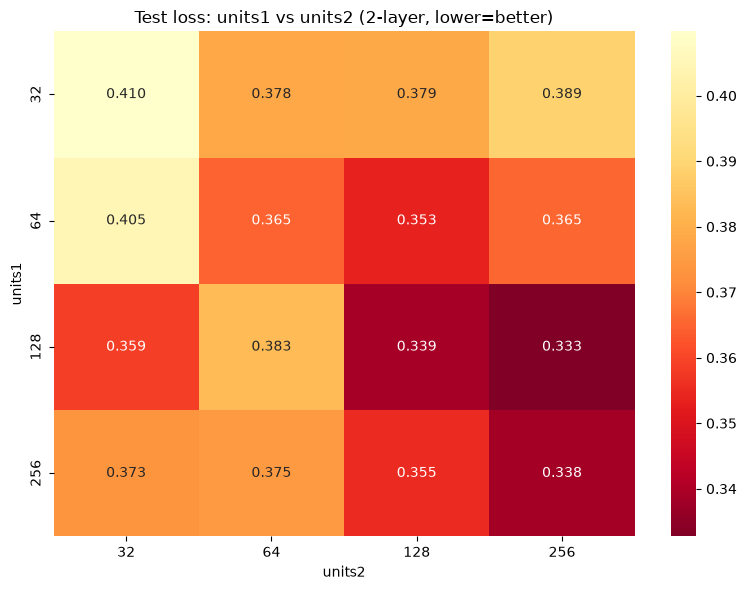

In [21]:
# Filter for the units grid search experiments (2-layer only)
df_units = df_results[df_results["experiment"].str.contains("units_")].copy()

if len(df_units) > 0:
    pivot = df_units.pivot_table(index="units1", columns="units2", values="test_loss")
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd_r", ax=ax)
    ax.set_title("Test loss: units1 vs units2 (2-layer, lower=better)")
    ax.set_xlabel("units2")
    ax.set_ylabel("units1")
    plt.tight_layout()
    plt.show()
else:
    logger.warning("No units grid data — run experiment 1 first")

### Depth vs units — test loss
Compare how model depth interacts with layer width.

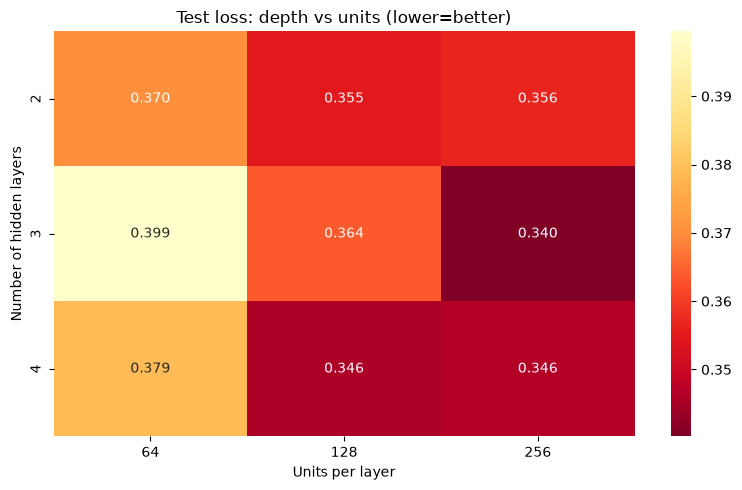

In [22]:
df_depth = df_results[df_results["experiment"].str.contains("depth")].copy()

if len(df_depth) > 0:
    pivot_depth = df_depth.pivot_table(index="num_layers", columns="units1", values="test_loss")
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot_depth, annot=True, fmt=".3f", cmap="YlOrRd_r", ax=ax)
    ax.set_title("Test loss: depth vs units (lower=better)")
    ax.set_xlabel("Units per layer")
    ax.set_ylabel("Number of hidden layers")
    plt.tight_layout()
    plt.show()
else:
    logger.warning("No depth data — run experiment 2 first")

### Learning rate, optimizer, batch size, and epochs comparisons

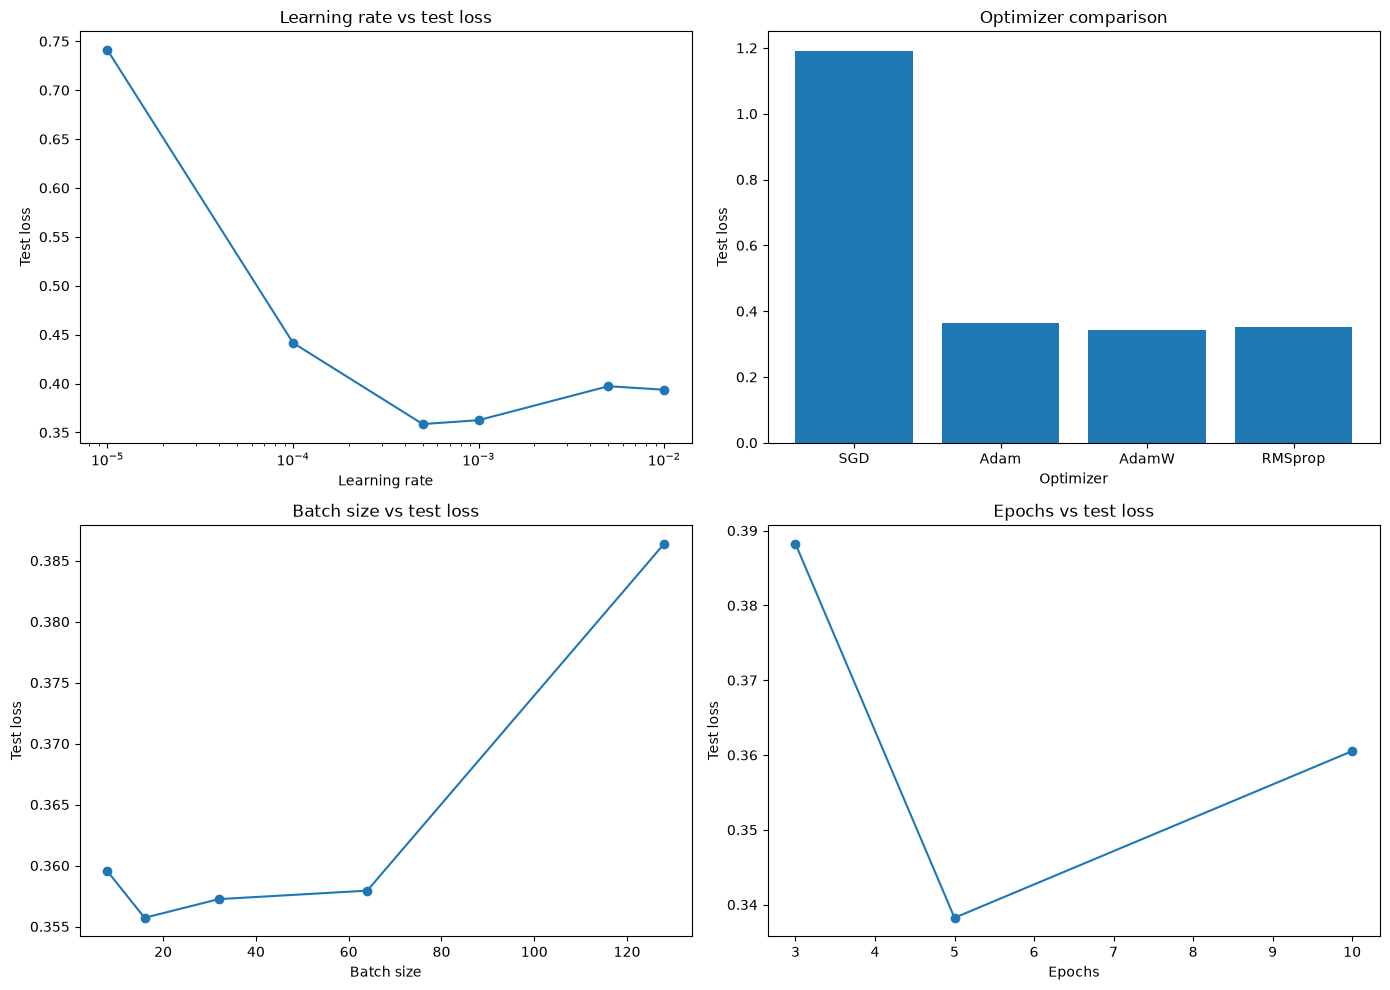

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Learning rate
df_lr = df_results[df_results["experiment"].str.startswith("lr_")]
if len(df_lr) > 0:
    axes[0, 0].plot(df_lr["lr"], df_lr["test_loss"], "o-")
    axes[0, 0].set_xscale("log")
    axes[0, 0].set_xlabel("Learning rate")
    axes[0, 0].set_ylabel("Test loss")
    axes[0, 0].set_title("Learning rate vs test loss")

# Optimizers
df_opt = df_results[df_results["experiment"].str.startswith("optim_")]
if len(df_opt) > 0:
    axes[0, 1].bar(df_opt["optimizer"], df_opt["test_loss"])
    axes[0, 1].set_xlabel("Optimizer")
    axes[0, 1].set_ylabel("Test loss")
    axes[0, 1].set_title("Optimizer comparison")

# Batch size
df_bs = df_results[df_results["experiment"].str.startswith("batch_")]
if len(df_bs) > 0:
    axes[1, 0].plot(df_bs["batchsize"], df_bs["test_loss"], "o-")
    axes[1, 0].set_xlabel("Batch size")
    axes[1, 0].set_ylabel("Test loss")
    axes[1, 0].set_title("Batch size vs test loss")

# Epochs
df_ep = df_results[df_results["experiment"].str.startswith("epochs_")]
if len(df_ep) > 0:
    axes[1, 1].plot(df_ep["epochs"], df_ep["test_loss"], "o-")
    axes[1, 1].set_xlabel("Epochs")
    axes[1, 1].set_ylabel("Test loss")
    axes[1, 1].set_title("Epochs vs test loss")

plt.tight_layout()
plt.show()

### TensorBoard
Launch TensorBoard to inspect detailed training/validation curves for all experiments.

In [24]:
%load_ext tensorboard
%tensorboard --logdir modellogs

Reusing TensorBoard on port 6006 (pid 4683), started 7:59:59 ago. (Use '!kill 4683' to kill it.)